<a href="https://colab.research.google.com/github/DulaniDeSilva/Computer-Vision/blob/main/k_means_implementation_on_iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.stats import mode
# from sklearn.datasets import load_iris

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite
/kaggle/input/extracted-iris-dataset/iris.txt


In [ ]:
class KMeans:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-6, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.centroids_list=[]
        self.labels = None

    def _initialize_centroids(self, X):
        np.random.seed(self.random_state)
        initial_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[initial_indices]
        self.centroids_list.append(self.centroids)

    def _assign_clusters(self, X):
        distances = np.sqrt(((X[:, np.newaxis] - self.centroids)**2).sum(axis=2))
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.array([X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else self.centroids[i] for i in range(self.n_clusters)])
        self.centroids_list.append(new_centroids)
        return new_centroids

    def _has_converged(self, old_centroids, new_centroids):
        distances = np.sqrt(((new_centroids - old_centroids)**2).sum(axis=1))
        return np.all(distances <= self.tol)

    def fit(self, X):
        self._initialize_centroids(X)
        for i in range(self.max_iter):
            self.labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, self.labels)
            if self._has_converged(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

    def predict(self, X):
        return self._assign_clusters(X)

    def inertia(self, X):
        distances = np.sqrt(((X[:, np.newaxis] - self.centroids)**2).sum(axis=2))
        closest_distances = np.min(distances, axis=1)
        return np.sum(closest_distances**2)


In [ ]:
def map_clusters_to_labels(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for i in range(kmeans.n_clusters):
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask])[0]
    return labels

In [ ]:
# Load iris dataset
# Load the data from the text file into a Pandas DataFrame
data = pd.read_csv('/kaggle/input/extracted-iris-dataset/iris.txt', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

# Exploratory Data Analysis

In [ ]:
# Initial Data Inspection
print("First few rows of the dataset:")
print(data.head())

# Display the data types of each column
print("\nData types of each column:")
print(data.dtypes)

print("\nSummary statistics:")
print(data.describe())

print("\nMissing values:")
print(data.isnull().sum())

First few rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Data types of each column:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Summary statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.850000     3.054000      3.758667     1.198667
std        0.830117     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5


Pairplot of the dataset:


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

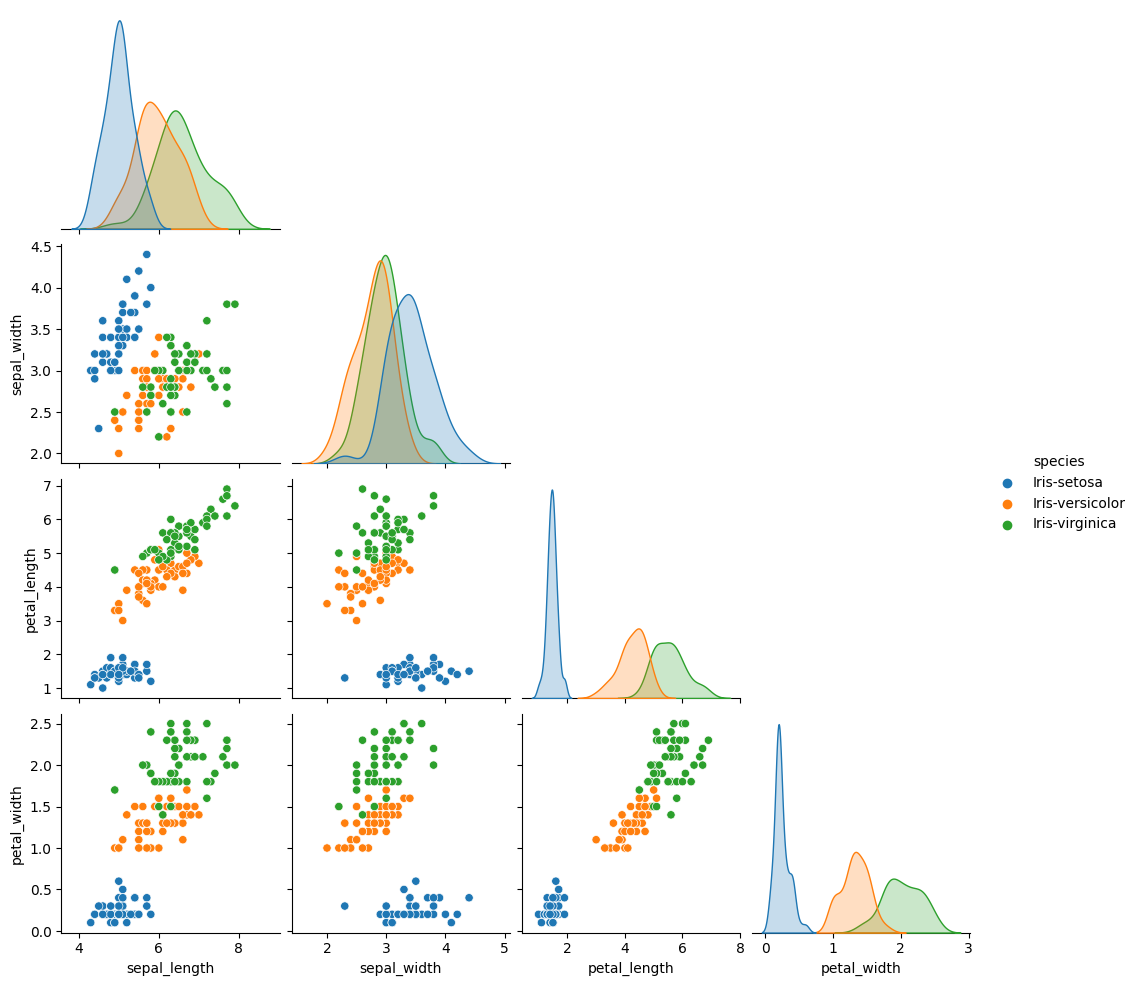

In [ ]:
# Replace Inf values with NaN and drop them
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Visualizing Data Distribution
print("\nPairplot of the dataset:")
sns.pairplot(data, hue='species', diag_kind='kde', corner=True)
plt.show()


Distribution plots for each feature:


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

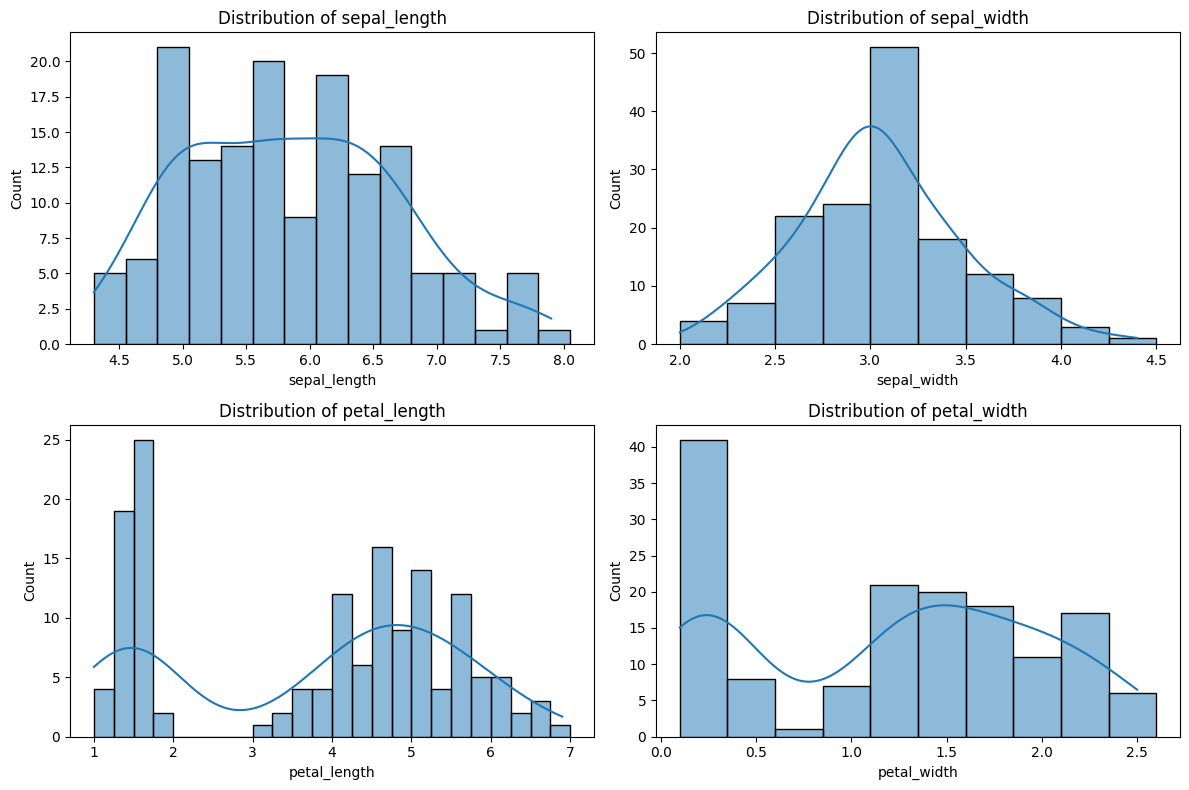

In [ ]:

print("\nDistribution plots for each feature:")
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns[:-1], 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[column], kde=True, binwidth=0.25)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()


In [ ]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Correlation matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.119429      0.870248     0.814888
sepal_width      -0.119429     1.000000     -0.420516    -0.356544
petal_length      0.870248    -0.420516      1.000000     0.962757
petal_width       0.814888    -0.356544      0.962757     1.000000

Heatmap of the correlation matrix:


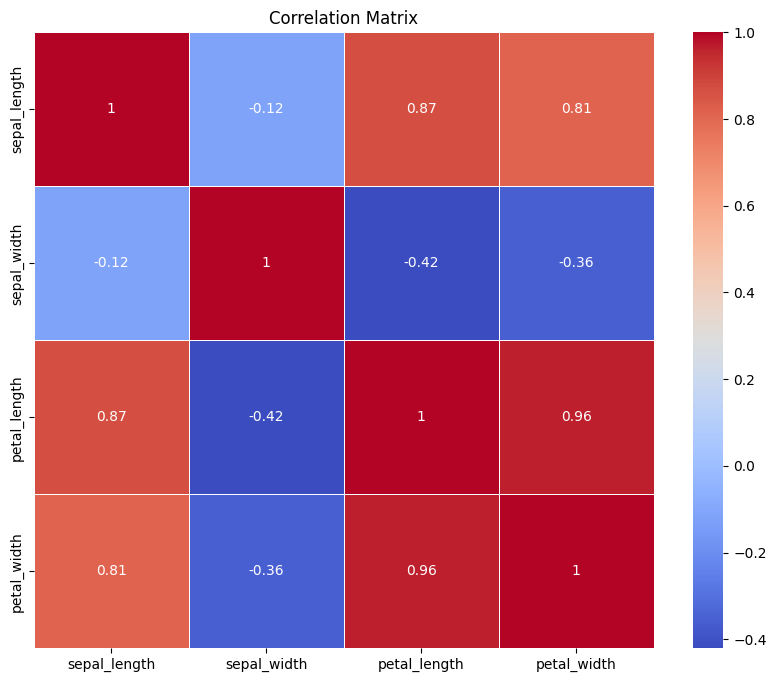

In [ ]:
# Drop the label column
data_numeric = data.drop(columns=['species'])

# Correlation Analysis
print("\nCorrelation matrix:")
correlation_matrix = data_numeric.corr()
print(correlation_matrix)

print("\nHeatmap of the correlation matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


Box plots for each feature by species:


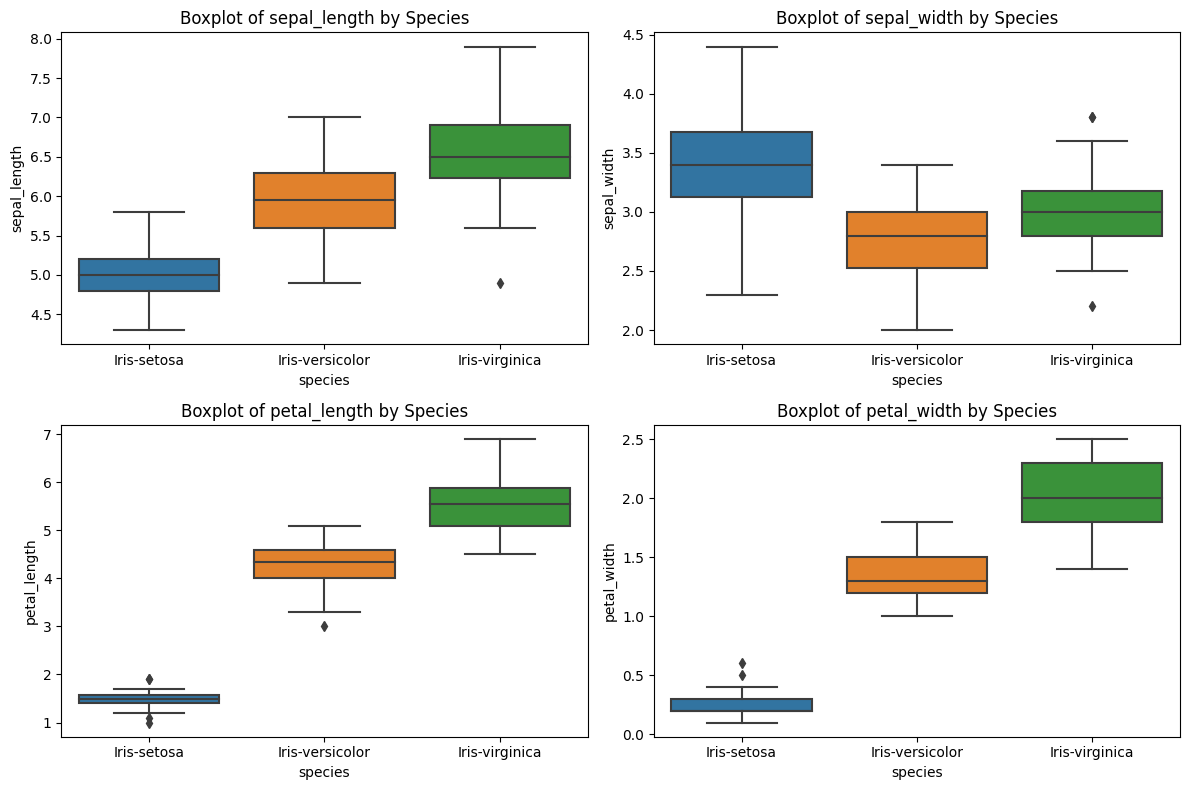

In [ ]:
# Box Plots to Identify Outliers
print("\nBox plots for each feature by species:")
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns[:-1], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='species', y=column, data=data)
    plt.title(f'Boxplot of {column} by Species')
plt.tight_layout()
plt.show()


Violin plots for each feature by species:


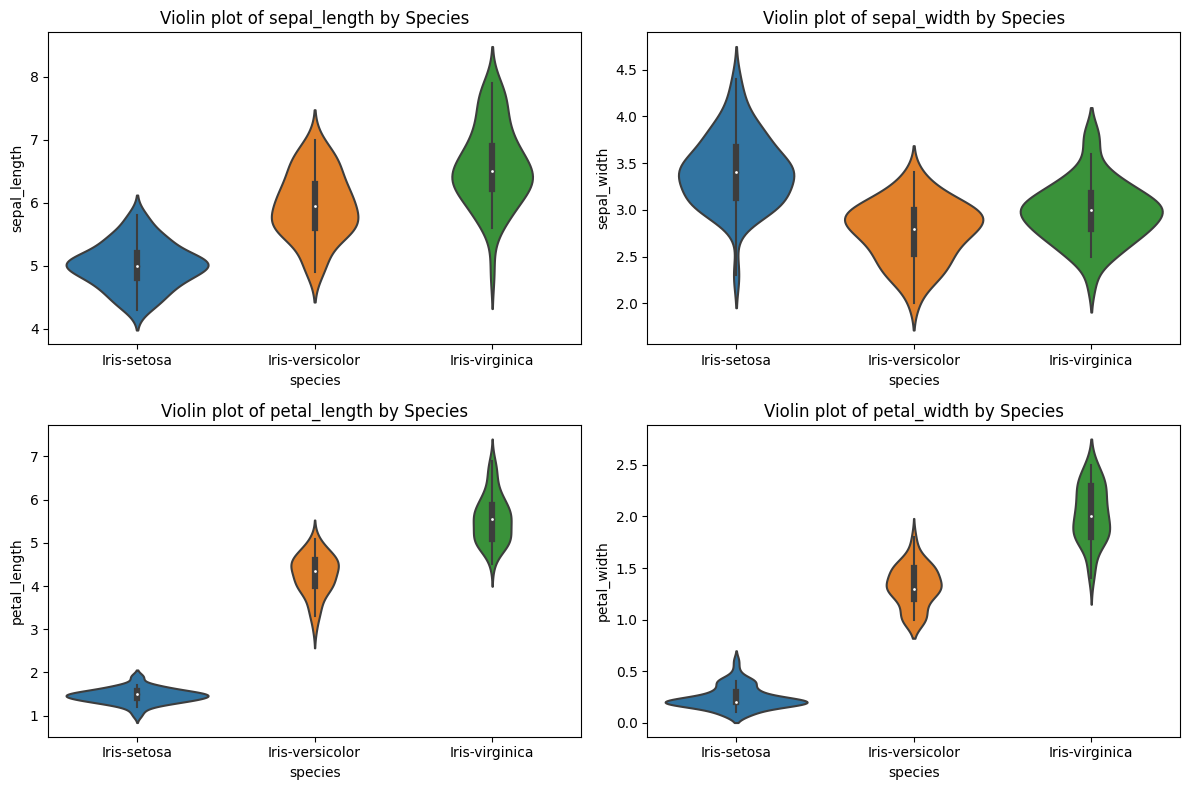

In [ ]:
# Violin Plots to Visualize Data Distribution by Category
print("\nViolin plots for each feature by species:")
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns[:-1], 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x='species', y=column, data=data)
    plt.title(f'Violin plot of {column} by Species')
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

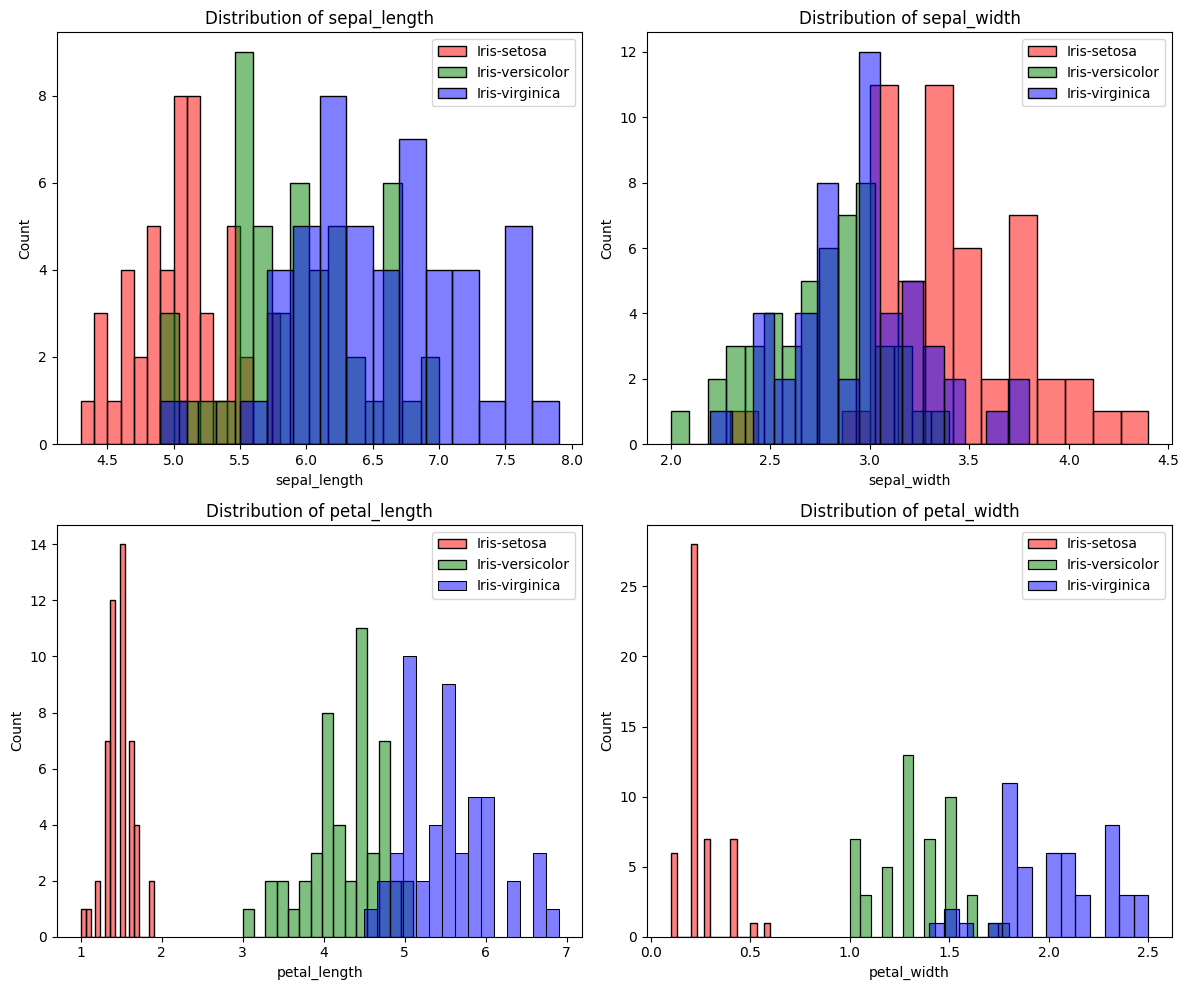

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Variable names
variables = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['red', 'green', 'blue']

# Draw histograms
for idx, variable in enumerate(variables):
    row, col = idx // 2, idx % 2
    for species, color in zip(data['species'].unique(), colors):
        subset = data[data['species'] == species]
        sns.histplot(subset[variable], ax=axes[row, col], kde=False, color=color, label=species, bins=15, alpha=0.5)
    axes[row, col].set_title(f'Distribution of {variable}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# Clustering the Data

Confusion Matrix:
 [[50  0  0]
 [ 0 47  3]
 [ 0 14 36]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.77      0.94      0.85        50
           2       0.92      0.72      0.81        50

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150


Accuracy: 0.8866666666666667


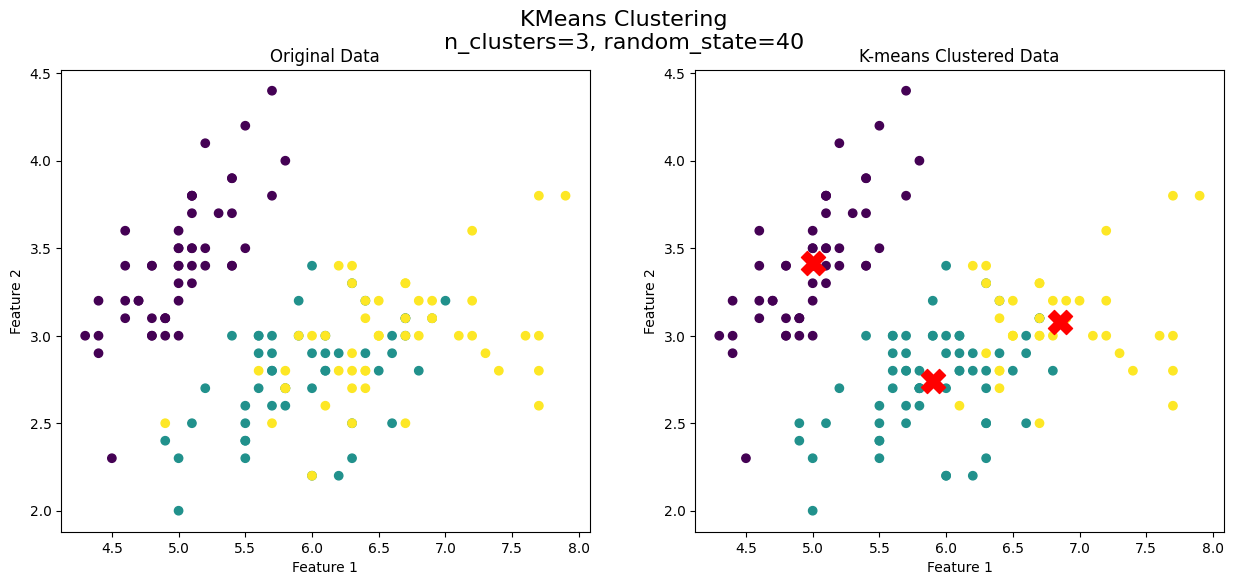

In [ ]:
# Extract features and labels
X = data.iloc[:,:-1].values.astype(float)
y_true_str = data.iloc[:, -1].values

# Convert string labels to numerical labels
label_mapping = {label: idx for idx, label in enumerate(np.unique(y_true_str))}
y_true = np.vectorize(label_mapping.get)(y_true_str)

# Instantiate and fit the KMeans model
n_clusters = 3
random_state = 40
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
# print(X)
kmeans.fit(X)

# Predict clusters for the input data
y_pred = kmeans.predict(X)

# Function to map clusters to labels (implement this function as needed)
def map_clusters_to_labels(y_true, y_pred):
    # Example implementation, you should adapt it based on your actual needs
    return y_pred

# Map the predicted labels to the true labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_mapped))
print("\nClassification Report:\n", classification_report(y_true, y_pred_mapped))
print("\nAccuracy:", accuracy_score(y_true, y_pred_mapped))

# Plot the original data and clustered data
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Original data
ax[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', marker='o')
ax[0].set_title("Original Data")
ax[0].set_xlabel('Feature 1')  # Replace with actual feature names if available
ax[0].set_ylabel('Feature 2')  # Replace with actual feature names if available

# Clustered data
ax[1].scatter(X[:, 0], X[:, 1], c=y_pred_mapped, cmap='viridis', marker='o')
ax[1].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=300, c='red', marker='X')
ax[1].set_title("K-means Clustered Data")
ax[1].set_xlabel('Feature 1')  # Replace with actual feature names if available
ax[1].set_ylabel('Feature 2')  # Replace with actual feature names if available

# Add suptitle with KMeans parameters
fig.suptitle(f"KMeans Clustering\nn_clusters={n_clusters}, random_state={random_state}", fontsize=16)

plt.show()

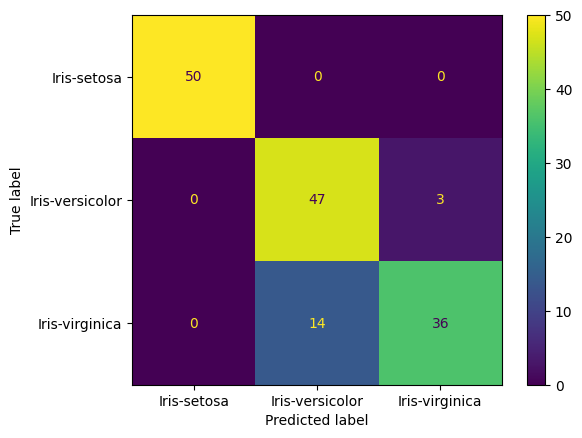


Accuracy: 0.8866666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.77      0.94      0.85        50
           2       0.92      0.72      0.81        50

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150

*****With feature Selection*****


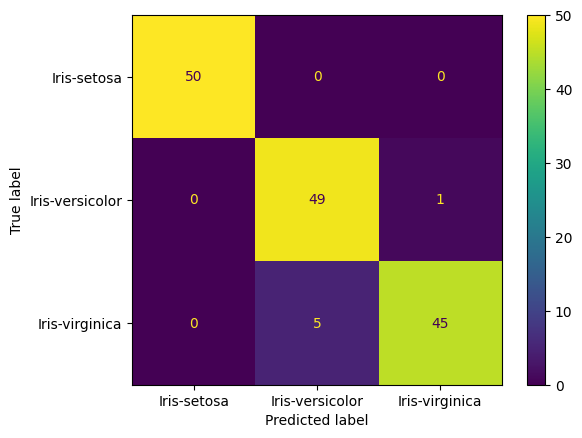


Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.91      0.98      0.94        50
           2       0.98      0.90      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150

*****With feature Selection + lowest inertia*****


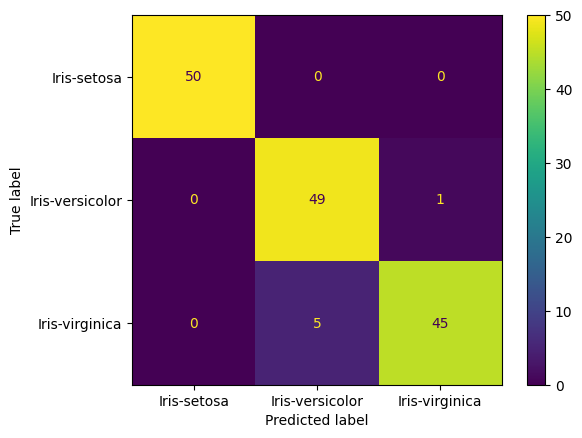


Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.91      0.98      0.94        50
           2       0.98      0.90      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment

# Extract features and labels
X = data.iloc[:, 0:-1].values.astype(float)
y_true_str = data.iloc[:, -1].values

# Convert string labels to numerical labels
label_mapping = {label: idx for idx, label in enumerate(np.unique(y_true_str))}
y_true = np.vectorize(label_mapping.get)(y_true_str)

# Instantiate and fit the KMeans model
n_clusters = 3
random_state = 40
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
kmeans.fit(X)

# Predict clusters for the input data
y_pred = kmeans.predict(X)

# Map predicted clusters to true labels
def map_clusters_to_labels(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    label_mapping = {old_label: new_label for old_label, new_label in zip(col_ind, row_ind)}
    y_pred_mapped = np.vectorize(label_mapping.get)(y_pred)
    return y_pred_mapped

# Map the predicted labels to the true labels
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred_mapped, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.keys())
disp.plot()
plt.show()
print("\nAccuracy:", accuracy_score(y_true, y_pred_mapped))
print("\nClassification Report:\n", classification_report(y_true, y_pred_mapped))

# Feature Selection- K-Means with only petal width
print("*****With feature Selection*****")
X_ = data.iloc[:, 3:-1].values.astype(float)
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
kmeans.fit(X_)
# Predict clusters for the input data
y_pred = kmeans.predict(X_)
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred_mapped, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.keys())
disp.plot()
plt.show()

print("\nAccuracy:", accuracy_score(y_true, y_pred_mapped))
print("\nClassification Report:\n", classification_report(y_true, y_pred_mapped))

#### For best_inertia
print("*****With feature Selection + lowest inertia*****")
best_inertia = float('inf')
n_init=100
for init in range(n_init):
    kmeans = KMeans(n_clusters=n_clusters,random_state=init)
    kmeans.fit(X_)
    inertia = kmeans.inertia(X_)
    if inertia < best_inertia:
        best_inertia = inertia
y_pred = kmeans.predict(X_)
y_pred_mapped = map_clusters_to_labels(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred_mapped, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_mapping.keys())
disp.plot()
plt.show()
print("\nAccuracy:", accuracy_score(y_true, y_pred_mapped))
print("\nClassification Report:\n", classification_report(y_true, y_pred_mapped))

In [ ]:

print(kmeans.centroids_list)
for centroid in kmeans.centroids_list:
    print(centroid,type(centroid),centroid.shape)


[array([[2.1],
       [0.2],
       [1.3]]), array([[2.07391304],
       [0.244     ],
       [1.33703704]]), array([[2.07391304],
       [0.244     ],
       [1.33703704]])]
[[2.1]
 [0.2]
 [1.3]] <class 'numpy.ndarray'> (3, 1)
[[2.07391304]
 [0.244     ]
 [1.33703704]] <class 'numpy.ndarray'> (3, 1)
[[2.07391304]
 [0.244     ]
 [1.33703704]] <class 'numpy.ndarray'> (3, 1)


Confusion Matrix:
 [[50  0  0]
 [ 0 37 13]
 [ 1 15 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       0.71      0.74      0.73        50
           2       0.72      0.68      0.70        50

    accuracy                           0.81       150
   macro avg       0.81      0.81      0.81       150
weighted avg       0.81      0.81      0.81       150


Accuracy: 0.8066666666666666


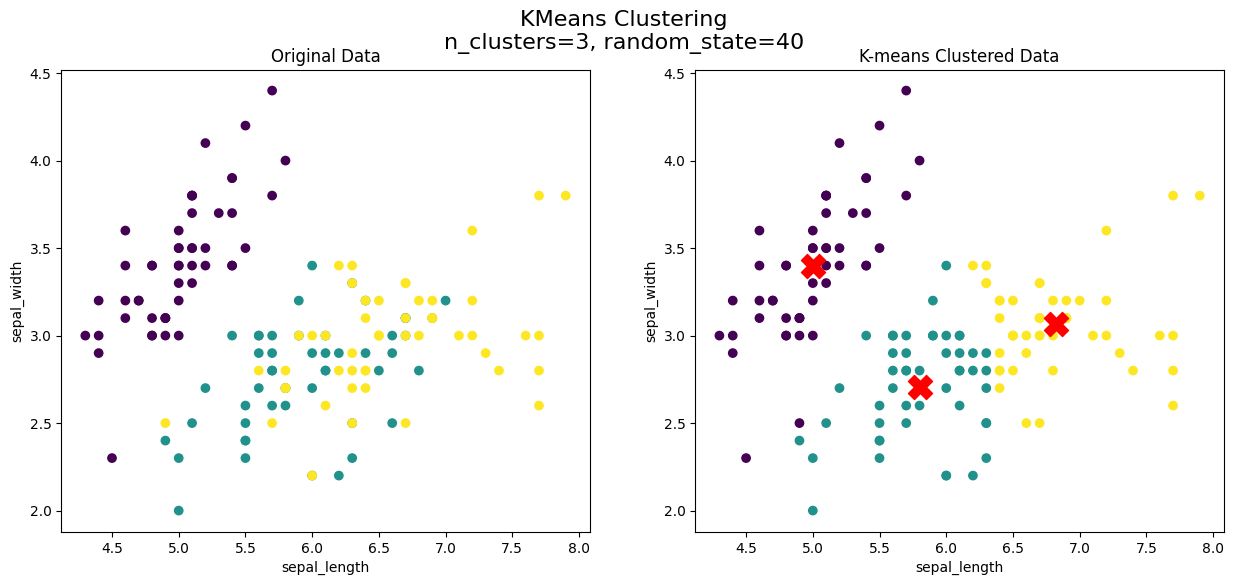

Confusion Matrix:
 [[50  0  0]
 [ 1 45  4]
 [ 0 13 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       0.78      0.90      0.83        50
           2       0.90      0.74      0.81        50

    accuracy                           0.88       150
   macro avg       0.89      0.88      0.88       150
weighted avg       0.89      0.88      0.88       150


Accuracy: 0.88


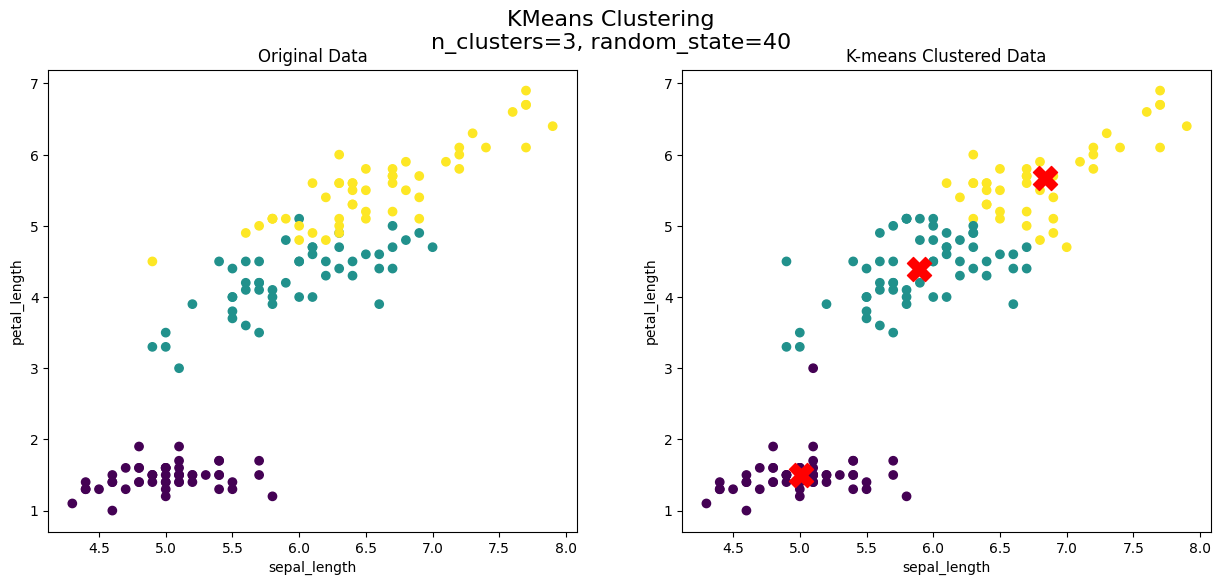

Confusion Matrix:
 [[50  0  0]
 [ 4 37  9]
 [ 0 13 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        50
           1       0.74      0.74      0.74        50
           2       0.80      0.74      0.77        50

    accuracy                           0.83       150
   macro avg       0.82      0.83      0.82       150
weighted avg       0.82      0.83      0.82       150


Accuracy: 0.8266666666666667


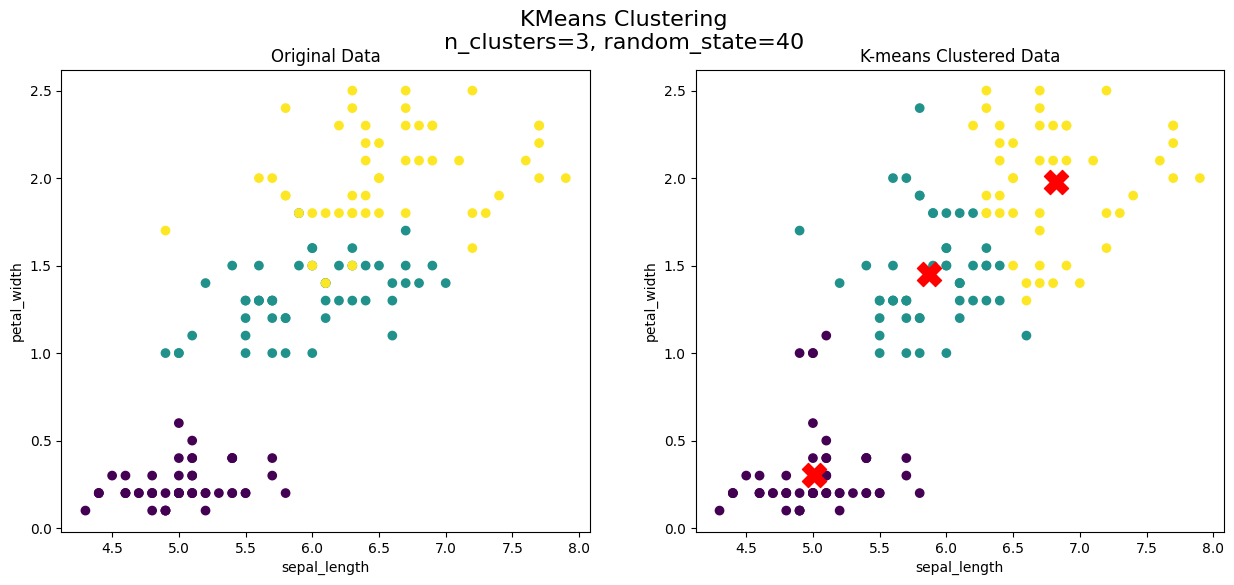

Confusion Matrix:
 [[50  0  0]
 [ 0 37 13]
 [ 1 15 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       0.71      0.74      0.73        50
           2       0.72      0.68      0.70        50

    accuracy                           0.81       150
   macro avg       0.81      0.81      0.81       150
weighted avg       0.81      0.81      0.81       150


Accuracy: 0.8066666666666666


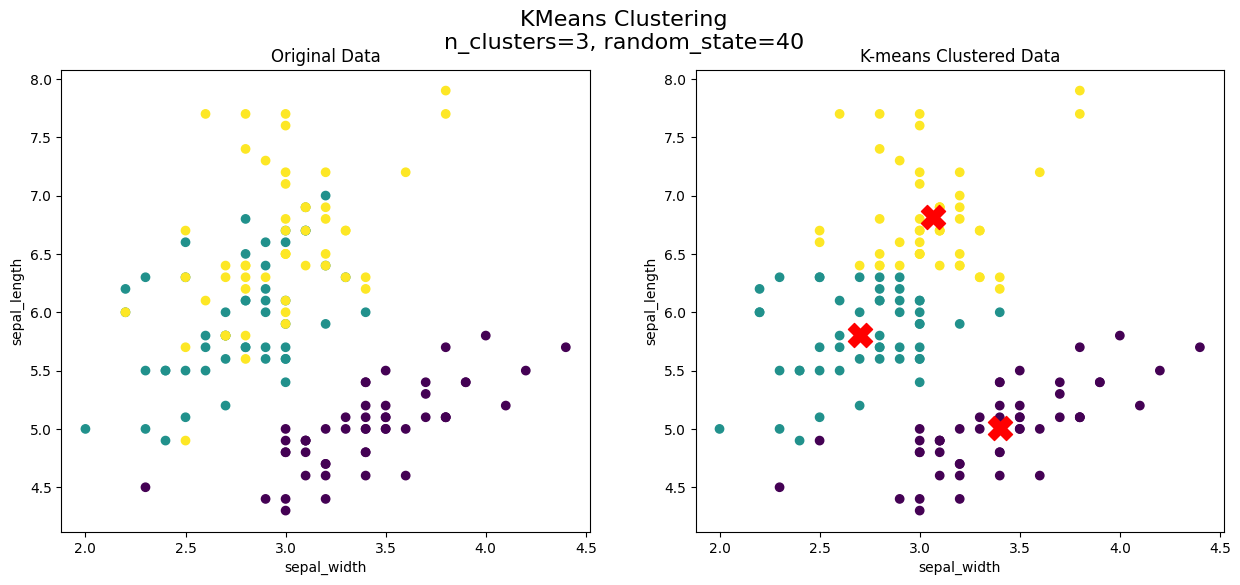

Confusion Matrix:
 [[50  0  0]
 [ 0 48  2]
 [ 0  9 41]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.84      0.96      0.90        50
           2       0.95      0.82      0.88        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150


Accuracy: 0.9266666666666666


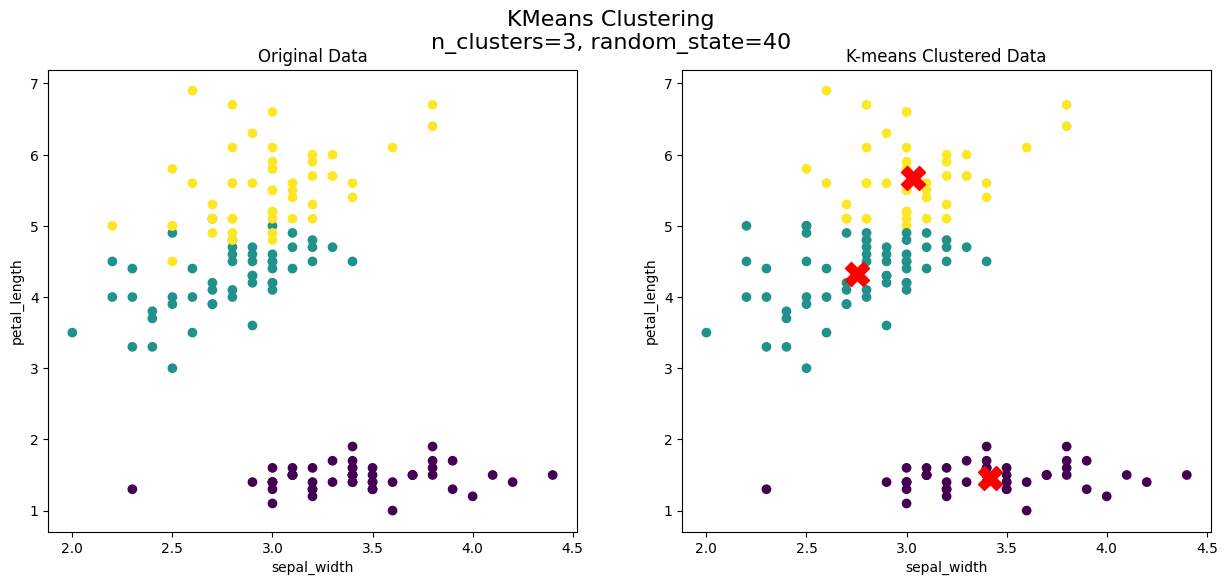

Confusion Matrix:
 [[49  1  0]
 [ 0 46  4]
 [ 0  6 44]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.87      0.92      0.89        50
           2       0.92      0.88      0.90        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150


Accuracy: 0.9266666666666666


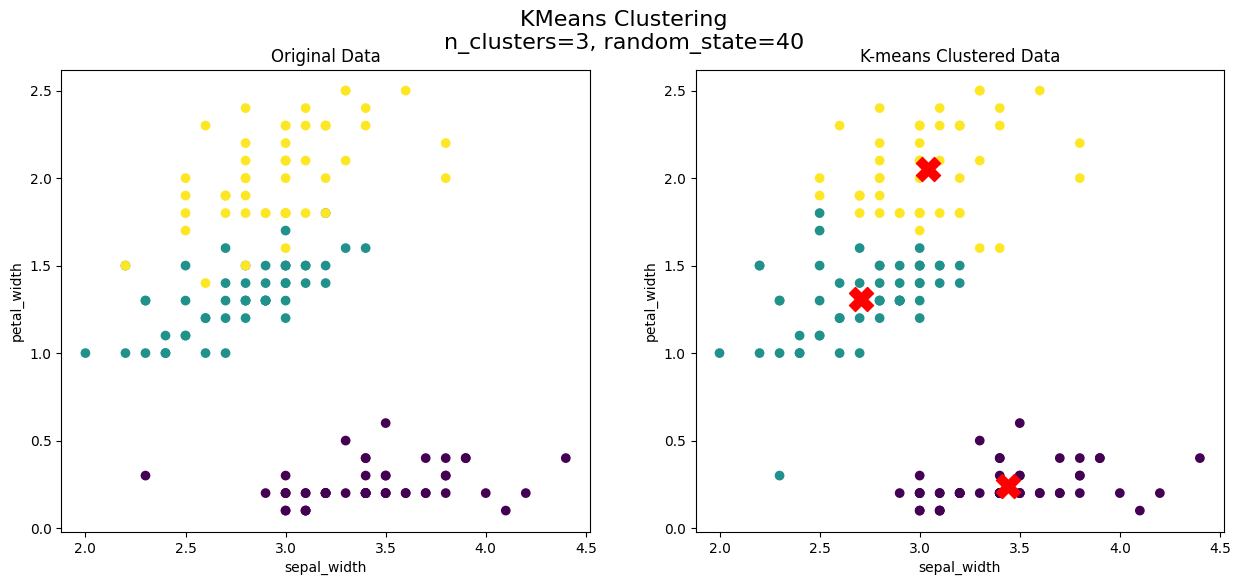

Confusion Matrix:
 [[50  0  0]
 [ 1 45  4]
 [ 0 13 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       0.78      0.90      0.83        50
           2       0.90      0.74      0.81        50

    accuracy                           0.88       150
   macro avg       0.89      0.88      0.88       150
weighted avg       0.89      0.88      0.88       150


Accuracy: 0.88


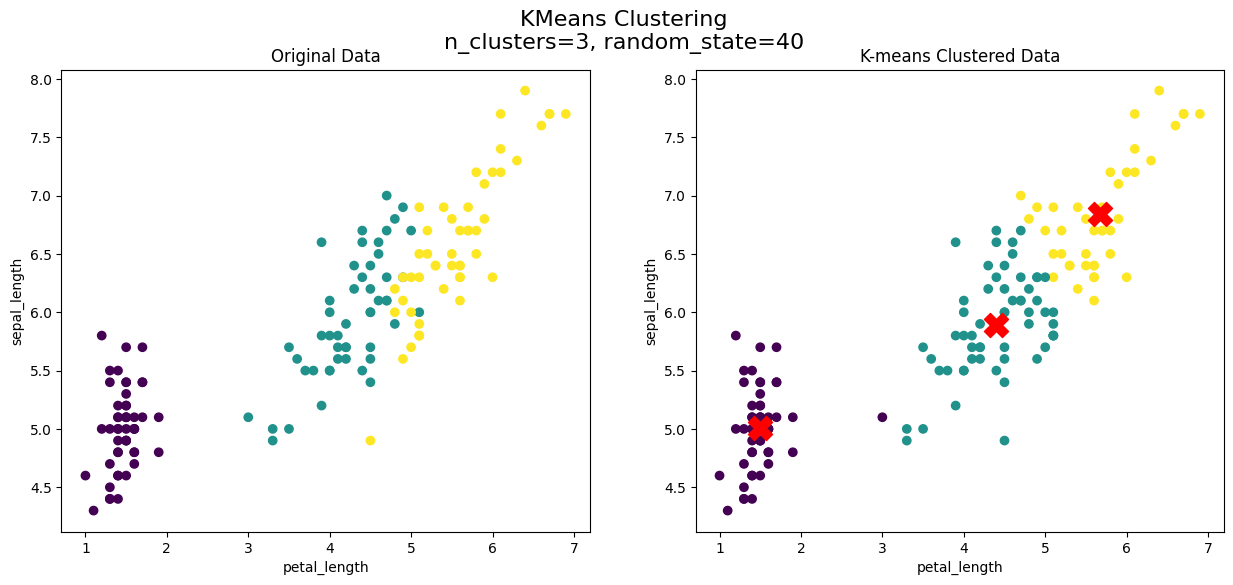

Confusion Matrix:
 [[50  0  0]
 [ 0 48  2]
 [ 0  9 41]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.84      0.96      0.90        50
           2       0.95      0.82      0.88        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150


Accuracy: 0.9266666666666666


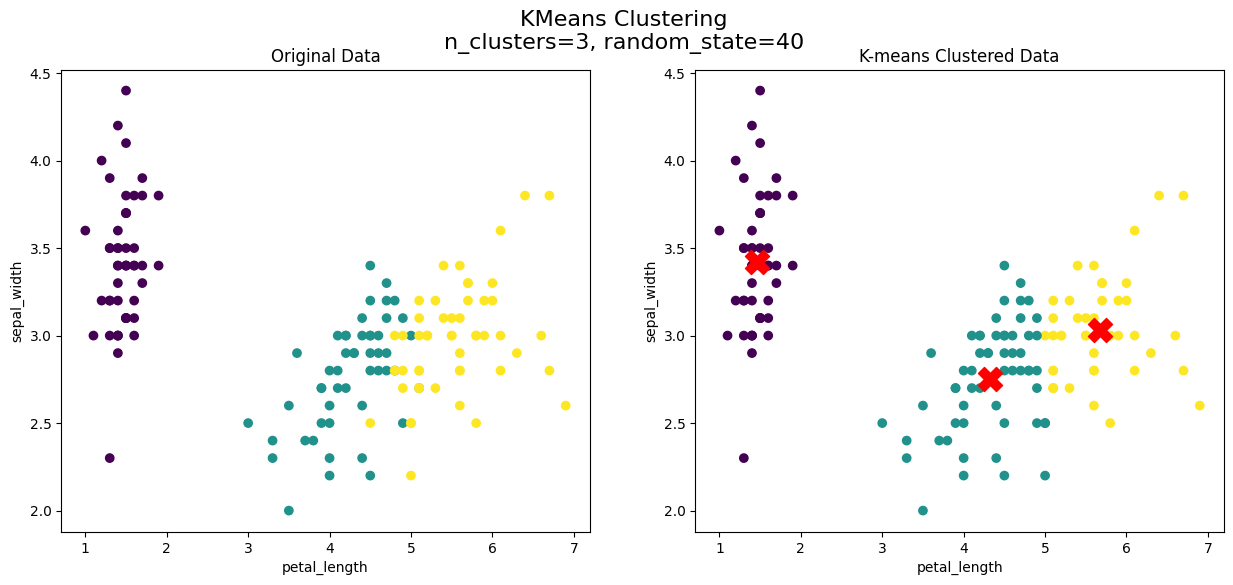

Confusion Matrix:
 [[50  0  0]
 [ 0 48  2]
 [ 0  6 44]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.89      0.96      0.92        50
           2       0.96      0.88      0.92        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


Accuracy: 0.9466666666666667


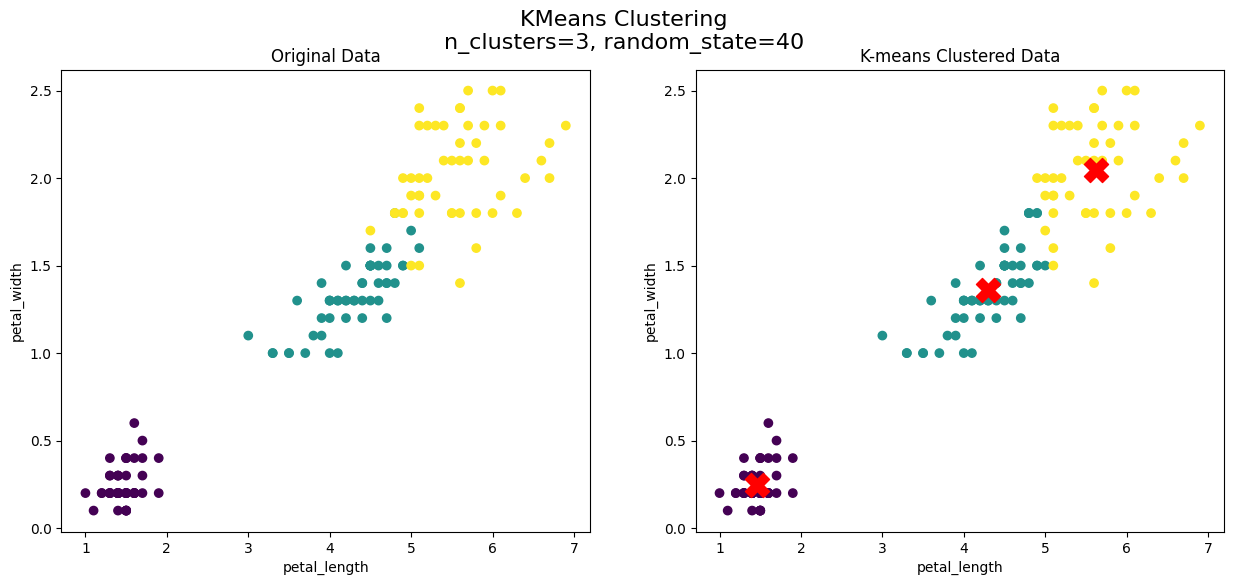

Confusion Matrix:
 [[50  0  0]
 [ 4 37  9]
 [ 0 13 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        50
           1       0.74      0.74      0.74        50
           2       0.80      0.74      0.77        50

    accuracy                           0.83       150
   macro avg       0.82      0.83      0.82       150
weighted avg       0.82      0.83      0.82       150


Accuracy: 0.8266666666666667


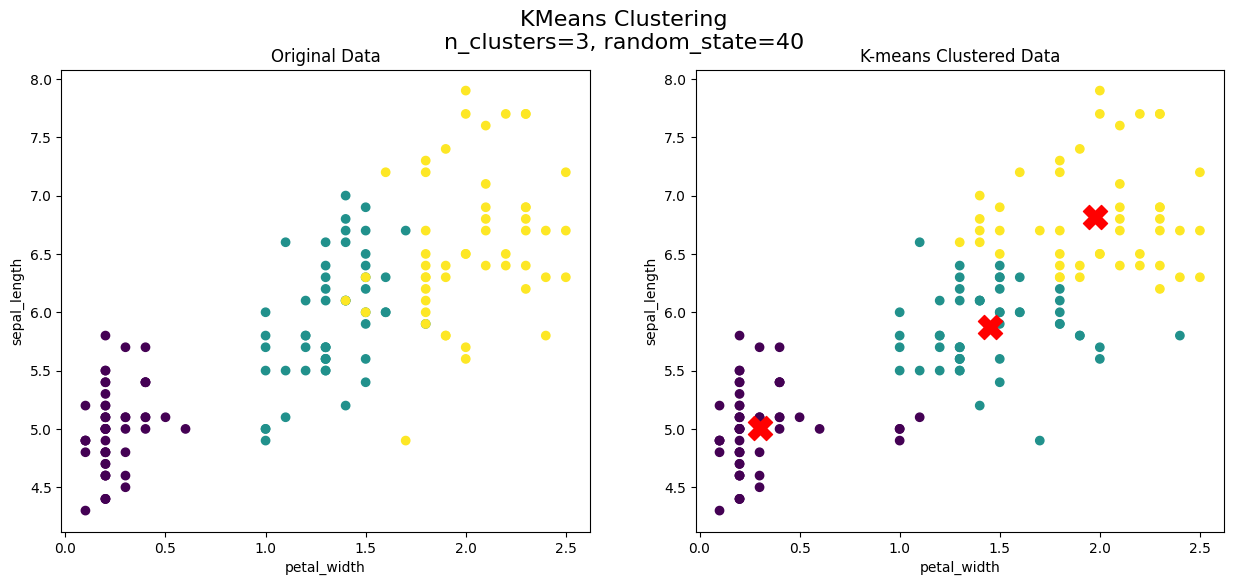

Confusion Matrix:
 [[49  1  0]
 [ 0 46  4]
 [ 0  6 44]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.87      0.92      0.89        50
           2       0.92      0.88      0.90        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150


Accuracy: 0.9266666666666666


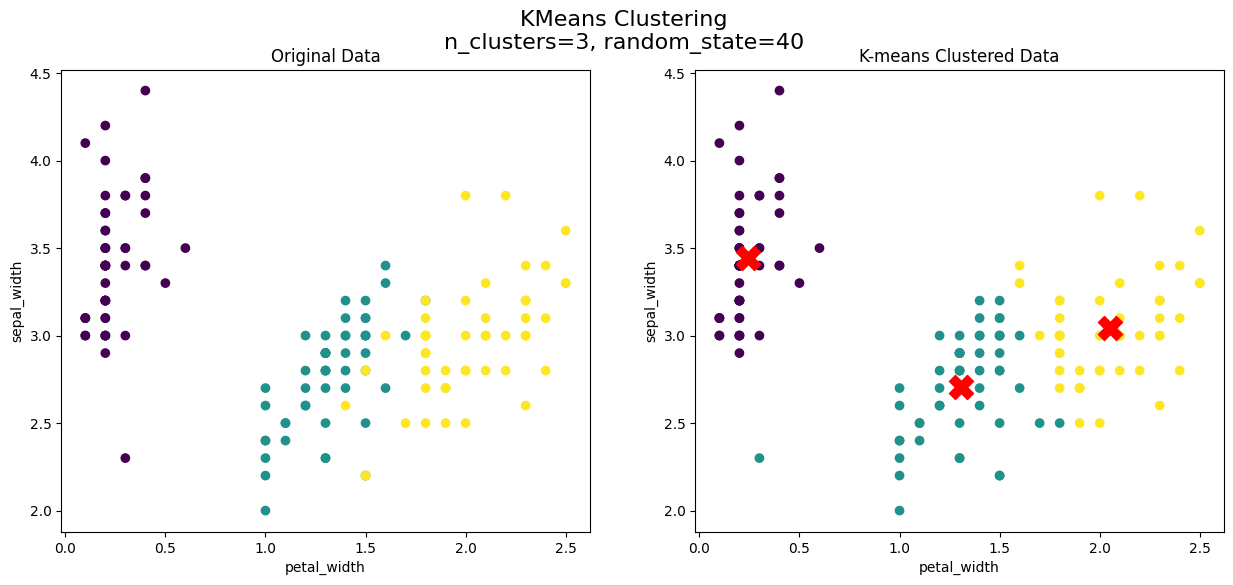

Confusion Matrix:
 [[50  0  0]
 [ 0 48  2]
 [ 0  6 44]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.89      0.96      0.92        50
           2       0.96      0.88      0.92        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


Accuracy: 0.9466666666666667


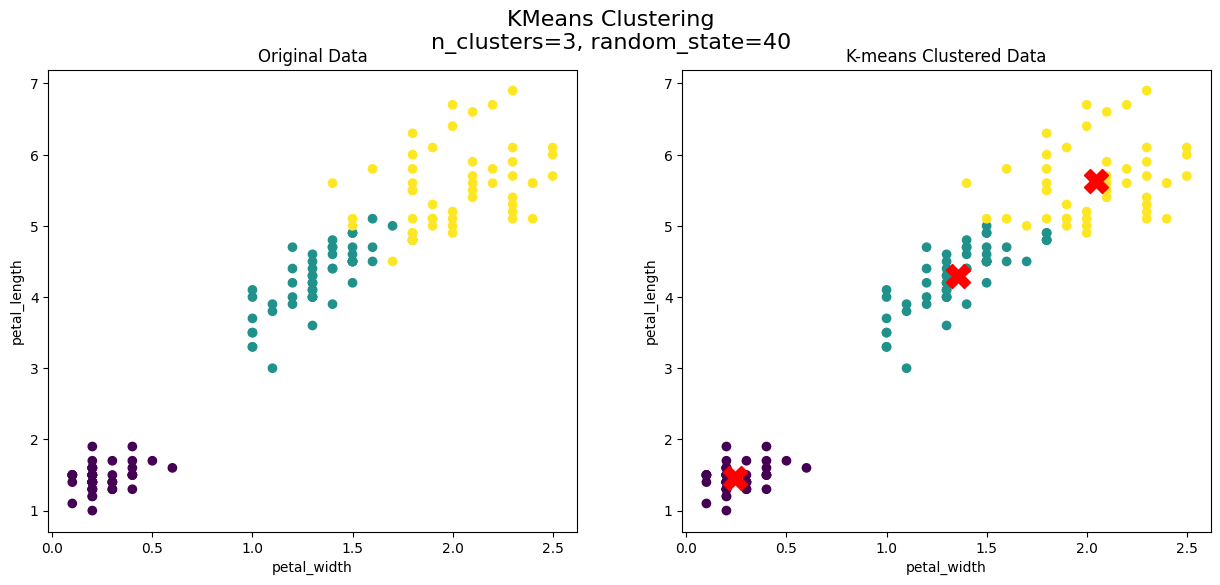

In [ ]:
# Extract features and labels
X = data.iloc[:,:-1].values.astype(float)
y_true_str = data.iloc[:, -1].values

# Convert string labels to numerical labels
label_mapping = {label: idx for idx, label in enumerate(np.unique(y_true_str))}
y_true = np.vectorize(label_mapping.get)(y_true_str)

# Instantiate and fit the KMeans model
n_clusters = 3
random_state = 40
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)


for i, column1 in enumerate(data.columns[:-1], 1):
    for i, column2 in enumerate(data.columns[:-1], 1):
        if column1 == column2:
            continue
        x = data[[column1,column2]].values.astype(float)
        kmeans.fit(x)
#         print(x)
        y_pred = kmeans.predict(x)
        y_pred_mapped = map_clusters_to_labels(y_true, y_pred)

        print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_mapped))
        print("\nClassification Report:\n", classification_report(y_true, y_pred_mapped))
        print("\nAccuracy:", accuracy_score(y_true, y_pred_mapped))

        # Plot the original data and clustered data
        fig, ax = plt.subplots(1, 2, figsize=(15, 6))

        # Original data
        ax[0].scatter(x[:, 0], x[:, 1], c=y_true, cmap='viridis', marker='o')
        ax[0].set_title("Original Data")
        ax[0].set_xlabel(column1)  # Replace with actual feature names if available
        ax[0].set_ylabel(column2)  # Replace with actual feature names if available

        # Clustered data
        ax[1].scatter(x[:, 0], x[:, 1], c=y_pred_mapped, cmap='viridis', marker='o')
        ax[1].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=300, c='red', marker='X')
        ax[1].set_title("K-means Clustered Data")
        ax[1].set_xlabel(column1)  # Replace with actual feature names if available
        ax[1].set_ylabel(column2)  # Replace with actual feature names if available

        # Add suptitle with KMeans parameters
        fig.suptitle(f"KMeans Clustering\nn_clusters={n_clusters}, random_state={random_state}", fontsize=16)

        plt.show()
